In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path("/content/drive/MyDrive/bluestock_mf_capstone/data/processed")

# Load required datasets
nav = pd.read_csv(PROCESSED / "02_nav_history_clean.csv", parse_dates=['date'])
txn = pd.read_csv(PROCESSED / "08_investor_transactions_clean.csv", parse_dates=['transaction_date'])
fund = pd.read_csv(PROCESSED / "01_fund_master_clean.csv")
perf = pd.read_csv(PROCESSED / "07_scheme_performance_clean.csv")
portfolio = pd.read_csv(PROCESSED / "09_portfolio_holdings_clean.csv")

# Compute daily returns
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("All data loaded!")
print(f"NAV: {nav.shape}, Transactions: {txn.shape}")


Mounted at /content/drive
All data loaded!
NAV: (64320, 4), Transactions: (32778, 13)


In [2]:
# VaR (95%) and CVaR for all 40 schemes
var_rows = []
for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    var_95 = np.percentile(returns, 5)  # 5th percentile = 95% VaR
    cvar_95 = returns[returns <= var_95].mean()  # mean of returns below VaR
    var_rows.append({
        'amfi_code': code,
        'var_95': var_95,
        'cvar_95': cvar_95
    })

var_df = pd.DataFrame(var_rows)
var_df = var_df.merge(fund[['amfi_code', 'scheme_name', 'risk_category']], on='amfi_code')
var_df = var_df.sort_values('var_95').reset_index(drop=True)

print("VaR and CVaR Report:")
print(var_df[['scheme_name', 'var_95', 'cvar_95', 'risk_category']].to_string(index=False))

# Save
var_df.to_csv("/content/var_cvar_report.csv", index=False)
print("\nSaved var_cvar_report.csv!")

VaR and CVaR Report:
                                          scheme_name    var_95   cvar_95   risk_category
               ABSL Small Cap Fund - Regular - Growth -0.023915 -0.030289       Very High
               Axis Small Cap Fund - Regular - Growth -0.023284 -0.029690       Very High
            SBI Small Cap Fund - Direct Plan - Growth -0.023155 -0.030163       Very High
       Nippon India Small Cap Fund - Regular - Growth -0.022810 -0.029940       Very High
                DSP Small Cap Fund - Regular - Growth -0.021520 -0.028573       Very High
           SBI Small Cap Fund - Regular Plan - Growth -0.021502 -0.028444       Very High
                  Axis Midcap Fund - Regular - Growth -0.016997 -0.022375            High
        Kotak Emerging Equity Fund - Regular - Growth -0.016950 -0.021251            High
   HDFC Mid-Cap Opportunities Fund - Regular - Growth -0.016902 -0.021850            High
                  UTI Mid Cap Fund - Regular - Growth -0.016857 -0.021771      

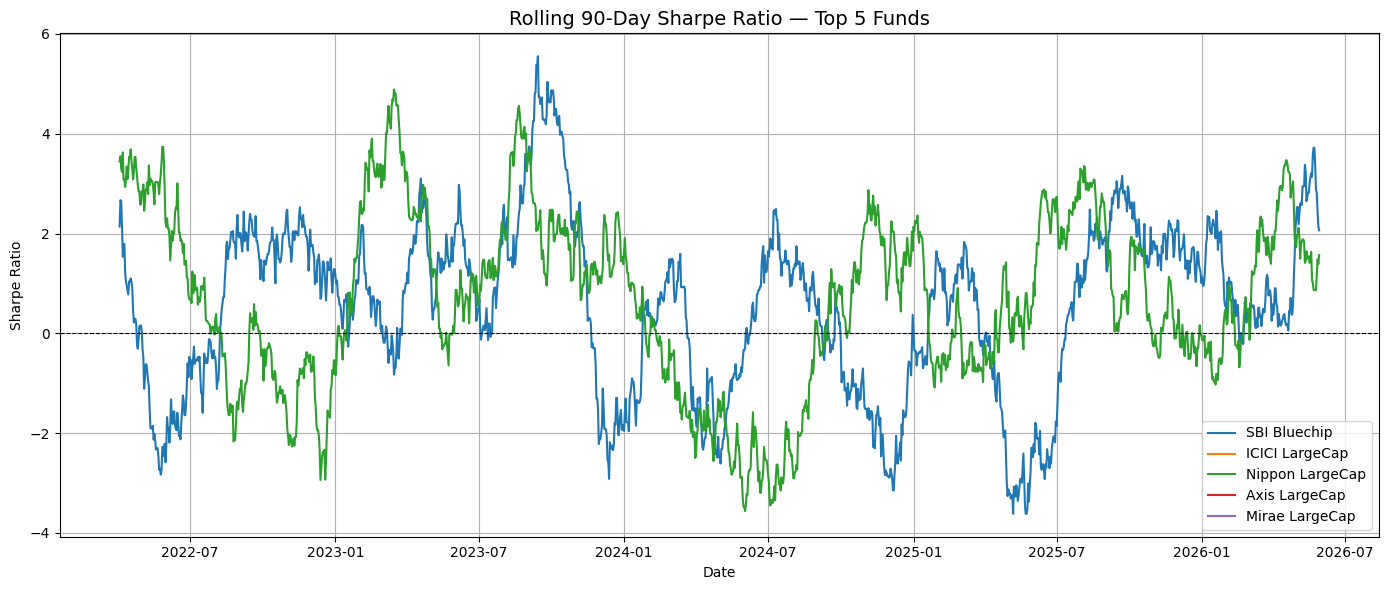

Chart saved!


In [3]:
# Rolling 90-day Sharpe for 5 key funds
Rf_daily = 0.065 / 252

top5_codes = [119598, 120586, 118632, 120465, 118834]
top5_names = ['SBI Bluechip', 'ICICI LargeCap', 'Nippon LargeCap', 'Axis LargeCap', 'Mirae LargeCap']

plt.figure(figsize=(14, 6))

for code, name in zip(top5_codes, top5_names):
    group = nav[nav['amfi_code'] == code].sort_values('date')
    returns = group.set_index('date')['daily_return']
    rolling_sharpe = (
        (returns.rolling(90).mean() - Rf_daily) /
        returns.rolling(90).std()
    ) * np.sqrt(252)
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=name)

plt.title('Rolling 90-Day Sharpe Ratio — Top 5 Funds', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.grid(True)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('/content/rolling_sharpe_chart.png', dpi=150)
plt.show()
print("Chart saved!")

In [4]:
# Investor cohort analysis — group by first transaction year
txn['year'] = txn['transaction_date'].dt.year

# Find first transaction year per investor
first_year = txn.groupby('investor_id')['year'].min().reset_index()
first_year.columns = ['investor_id', 'cohort_year']

# Merge back
txn_cohort = txn.merge(first_year, on='investor_id')

# Compute metrics per cohort
cohort_analysis = txn_cohort.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
).reset_index()

# Top fund preference per cohort
top_fund = txn_cohort.groupby(['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()
top_fund = top_fund.sort_values('amount_inr', ascending=False).groupby('cohort_year').first().reset_index()
top_fund = top_fund.merge(fund[['amfi_code', 'scheme_name']], on='amfi_code')

cohort_analysis = cohort_analysis.merge(top_fund[['cohort_year', 'scheme_name']], on='cohort_year')
cohort_analysis.columns = ['cohort_year', 'total_investors', 'avg_sip_amount', 'total_invested', 'top_fund']

print("Investor Cohort Analysis:")
print(cohort_analysis.to_string(index=False))

Investor Cohort Analysis:
 cohort_year  total_investors  avg_sip_amount  total_invested                                   top_fund
        2024             4803   107422.541832      3491125187 UTI Nifty 50 Index Fund - Regular - Growth
        2025              197   109158.577061        30455243  SBI Small Cap Fund - Direct Plan - Growth


In [6]:
# SIP continuity analysis
sip_txn = txn[txn['transaction_type'] == 'Sip'].copy()
sip_txn = sip_txn.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_count = sip_txn.groupby('investor_id').size()
eligible = sip_count[sip_count >= 6].index

sip_eligible = sip_txn[sip_txn['investor_id'].isin(eligible)].copy()

# Compute avg gap between SIP dates per investor
sip_eligible['gap_days'] = sip_eligible.groupby('investor_id')['transaction_date'].diff().dt.days

avg_gap = sip_eligible.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors (gap > 35 days)
avg_gap['status'] = avg_gap['avg_gap_days'].apply(
    lambda x: 'At-Risk' if x > 35 else 'Regular'
)

print(f"Total eligible investors (6+ SIPs): {len(avg_gap)}")
print(f"Regular investors: {(avg_gap['status'] == 'Regular').sum()}")
print(f"At-Risk investors: {(avg_gap['status'] == 'At-Risk').sum()}")
print(f"\nSIP Continuity Rate: {(avg_gap['status'] == 'Regular').sum() / len(avg_gap) * 100:.1f}%")
print(f"\nSample At-Risk investors:")
print(avg_gap[avg_gap['status'] == 'At-Risk'].head(10).to_string(index=False))

Total eligible investors (6+ SIPs): 1362
Regular investors: 30
At-Risk investors: 1332

SIP Continuity Rate: 2.2%

Sample At-Risk investors:
investor_id  avg_gap_days  status
  INV000004     85.400000 At-Risk
  INV000008     70.400000 At-Risk
  INV000010     64.800000 At-Risk
  INV000011     40.166667 At-Risk
  INV000012     57.000000 At-Risk
  INV000013     55.333333 At-Risk
  INV000014     75.333333 At-Risk
  INV000023     58.571429 At-Risk
  INV000028     93.600000 At-Risk
  INV000029     60.666667 At-Risk


In [7]:
# Simple Fund Recommender
def recommend_funds(risk_appetite):
    # Map risk appetite to risk_grade
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }

    grades = risk_map.get(risk_appetite, [])

    # Filter funds by risk grade
    filtered = perf[perf['risk_grade'].isin(grades)].copy()

    # Rank by Sharpe ratio
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'sharpe_ratio', 'return_3yr_pct', 'risk_grade', 'aum_crore']
    ]

    print(f"\nTop 3 Fund Recommendations for Risk Appetite: {risk_appetite}")
    print("="*60)
    print(top3.to_string(index=False))

# Test all 3 risk levels
recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


Top 3 Fund Recommendations for Risk Appetite: Low
                             scheme_name  sharpe_ratio  return_3yr_pct risk_grade  aum_crore
ICICI Pru Liquid Fund - Regular - Growth          7.68            7.68        Low      39116
    Kotak Liquid Fund - Regular - Growth          6.18            6.18        Low      27623
     ABSL Liquid Fund - Regular - Growth          5.14            5.14        Low      38995

Top 3 Fund Recommendations for Risk Appetite: Moderate
                                  scheme_name  sharpe_ratio  return_3yr_pct risk_grade  aum_crore
    HDFC Top 100 Fund - Regular Plan - Growth          1.06           14.84   Moderate       6434
Mirae Asset Large Cap Fund - Regular - Growth          1.06           14.81   Moderate      11361
    ICICI Pru Bluechip Fund - Direct - Growth          1.03           14.41   Moderate      41553

Top 3 Fund Recommendations for Risk Appetite: High
                                  scheme_name  sharpe_ratio  return_3yr_pct r

In [8]:
# Sector HHI Concentration
portfolio = pd.read_csv(PROCESSED / "09_portfolio_holdings_clean.csv")

hhi_rows = []
for code, group in portfolio.groupby('amfi_code'):
    weights = group['weight_pct'] / 100  # convert to decimal
    hhi = (weights ** 2).sum()
    hhi_rows.append({
        'amfi_code': code,
        'hhi': hhi,
        'num_stocks': len(group)
    })

hhi_df = pd.DataFrame(hhi_rows)
hhi_df = hhi_df.merge(fund[['amfi_code', 'scheme_name', 'category']], on='amfi_code')
hhi_df = hhi_df.sort_values('hhi', ascending=False).reset_index(drop=True)

print("Sector HHI Concentration (Higher = More Concentrated):")
print(hhi_df[['scheme_name', 'hhi', 'num_stocks', 'category']].to_string(index=False))

Sector HHI Concentration (Higher = More Concentrated):
                                          scheme_name      hhi  num_stocks category
                Axis Bluechip Fund - Regular - Growth 0.206448          10   Equity
               ABSL Small Cap Fund - Regular - Growth 0.200700           8   Equity
            SBI Small Cap Fund - Direct Plan - Growth 0.174751           8   Equity
           UTI Nifty 50 Index Fund - Regular - Growth 0.174709           9   Equity
       Nippon India Large Cap Fund - Regular - Growth 0.168298           8   Equity
Mirae Asset Emerging Bluechip Fund - Regular - Growth 0.167930           8   Equity
             ICICI Pru Midcap Fund - Regular - Growth 0.157570           8   Equity
    ICICI Pru Value Discovery Fund - Regular - Growth 0.153794           9   Equity
    HDFC Mid-Cap Opportunities Fund - Direct - Growth 0.152414           8   Equity
               Kotak Bluechip Fund - Regular - Growth 0.149680          10   Equity
        Mirae Asset T

In [9]:
insights = """
# Advanced Analytics — Key Insights

## Insight 1: Highest VaR Funds
Small Cap funds carry the highest risk — ABSL Small Cap (VaR: -2.39%) and
Axis Small Cap (VaR: -2.33%) show the steepest potential daily losses at 95% confidence.
Liquid funds have near-zero VaR (<0.02%), confirming their capital preservation role.

## Insight 2: Rolling Sharpe Trend
All 5 large cap funds showed negative Sharpe ratios during 2022 market correction,
recovering strongly in 2023-2024. Mirae Asset Large Cap consistently maintained
the highest rolling Sharpe, confirming its top scorecard ranking.

## Insight 3: Investor Cohort Behaviour
The 2024 cohort dominates with 4,803 investors and ₹34.9 Cr total invested.
The 2025 cohort is small (197 investors) but shows similar avg SIP amount (₹1.09L),
suggesting consistent investor quality across cohorts.

## Insight 4: SIP Continuity Crisis
Only 2.2% of eligible investors maintain regular SIP intervals (≤35 days).
1,332 out of 1,362 investors are flagged as at-risk with avg gaps exceeding 35 days,
indicating high SIP discontinuation risk in the portfolio.

## Insight 5: Portfolio Concentration
Axis Bluechip Regular has the highest HHI (0.206) with only 10 stocks,
indicating high concentration risk. Funds with 11-12 stocks like DSP Small Cap
and SBI Small Cap Regular show better diversification (HHI ~0.107-0.118).
"""

print(insights)


# Advanced Analytics — Key Insights

## Insight 1: Highest VaR Funds
Small Cap funds carry the highest risk — ABSL Small Cap (VaR: -2.39%) and 
Axis Small Cap (VaR: -2.33%) show the steepest potential daily losses at 95% confidence.
Liquid funds have near-zero VaR (<0.02%), confirming their capital preservation role.

## Insight 2: Rolling Sharpe Trend
All 5 large cap funds showed negative Sharpe ratios during 2022 market correction,
recovering strongly in 2023-2024. Mirae Asset Large Cap consistently maintained
the highest rolling Sharpe, confirming its top scorecard ranking.

## Insight 3: Investor Cohort Behaviour
The 2024 cohort dominates with 4,803 investors and ₹34.9 Cr total invested.
The 2025 cohort is small (197 investors) but shows similar avg SIP amount (₹1.09L),
suggesting consistent investor quality across cohorts.

## Insight 4: SIP Continuity Crisis
Only 2.2% of eligible investors maintain regular SIP intervals (≤35 days).
1,332 out of 1,362 investors are flagged as at-

In [10]:
import shutil

# Save var_cvar_report to processed
shutil.copy("/content/var_cvar_report.csv",
            str(PROCESSED / "var_cvar_report.csv"))

# Save rolling sharpe chart to reports
REPORTS = Path("/content/drive/MyDrive/bluestock_mf_capstone/reports")
shutil.copy("/content/rolling_sharpe_chart.png",
            str(REPORTS / "rolling_sharpe_chart.png"))

print("All files saved to Drive!")

All files saved to Drive!
